<h2><center>Лабораторна робота №6: розширення спектру (spread spectrum)</center></h2>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from modulation_dsss import Sender as DSSS_Sender, Receiver as DSSS_Receiver
from modulation_fhss import Sender as FHSS_Sender, Receiver as FHSS_Receiver
from modulation_thss import Sender as THSS_Sender, Receiver as THSS_Receiver

In [2]:
message = 'This is a test message that should not get corrupted!'   # Повідомлення що модулюється, передається із зашумленням та демоделюється
seed = 42                                                           # Параметр для спільної псевдовипадкової генерації PN-коду
chip_rate = 4                                                       # Розширення спектра
noise_levels = [nl / 10 for nl in range(0, 15)]                     # Різні рівні (стд. відхилення) Гауссівського шуму

In [3]:
# Шкідливий "посередник" між передавачем і приймачем, що накладає шум на сигнал (модульоване повідомлення)
class MaliciousObserver:
    def __init__(self, noise_level=0.1):
        self.noise_level = noise_level
    
    def add_noise(self, signal):
        # Зашумлення - адитивне накладання Гауссівського шуму
        noise = np.random.normal(0, self.noise_level, signal.shape)
        return signal + noise

In [4]:
# Тестування шумостійкості різних методів розширення спектру: 
# повертає залежність кількості втрачених символів повідомлення від рівня шуму
def test_modulation(sender_class, receiver_class):
    sender = sender_class(seed=seed, chip_rate=chip_rate)
    modulated_message = sender.modulate(message)
    receiver = receiver_class(seed=seed, chip_rate=chip_rate)

    losses = {}

    for nl in noise_levels:
        observer = MaliciousObserver(noise_level=nl)
        noisy_message = observer.add_noise(modulated_message)
        demodulated_message = receiver.demodulate(noisy_message)
        if message != demodulated_message:
            wrong_characters_count = sum([1 for i in range(len(message)) if message[i] != demodulated_message[i]])
            losses[nl] = wrong_characters_count
        else:
            losses[nl] = 0
    return losses

In [5]:
# Експерименти: перевірка методів DSSS, FHSS, THSS і збір статистики
losses_per_method = {}
senders = [DSSS_Sender, FHSS_Sender, THSS_Sender]
receivers = [DSSS_Receiver, FHSS_Receiver, THSS_Receiver]
method_names = ['DSSS', 'FHSS', 'THSS']
for sender_class, receiver_class, method_name in zip(senders, receivers, method_names):
    losses = test_modulation(sender_class=sender_class, receiver_class=receiver_class)
    losses_per_method[method_name] = losses
    if all([losses[nl] == 0 for nl in noise_levels]):
        print(f'Метод розширення спектру {method_name} працює бездоганно!')
    else:
        print(f'\tДослідження шумостійкості методу {method_name}:')
        for nl in noise_levels:
            loss = losses[nl]
            loss_percent = loss / len(message) * 100.0
            print(f'Втрати при рівні шуму {nl:.1f}: {loss} символів ({loss_percent:.2f}%)')

	Дослідження шумостійкості методу DSSS:
Втрати при рівні шуму 0.0: 0 символів (0.00%)
Втрати при рівні шуму 0.1: 0 символів (0.00%)
Втрати при рівні шуму 0.2: 0 символів (0.00%)
Втрати при рівні шуму 0.3: 0 символів (0.00%)
Втрати при рівні шуму 0.4: 2 символів (3.77%)
Втрати при рівні шуму 0.5: 2 символів (3.77%)
Втрати при рівні шуму 0.6: 14 символів (26.42%)
Втрати при рівні шуму 0.7: 39 символів (73.58%)
Втрати при рівні шуму 0.8: 41 символів (77.36%)
Втрати при рівні шуму 0.9: 50 символів (94.34%)
Втрати при рівні шуму 1.0: 48 символів (90.57%)
Втрати при рівні шуму 1.1: 52 символів (98.11%)
Втрати при рівні шуму 1.2: 52 символів (98.11%)
Втрати при рівні шуму 1.3: 53 символів (100.00%)
Втрати при рівні шуму 1.4: 51 символів (96.23%)
	Дослідження шумостійкості методу FHSS:
Втрати при рівні шуму 0.0: 0 символів (0.00%)
Втрати при рівні шуму 0.1: 0 символів (0.00%)
Втрати при рівні шуму 0.2: 1 символів (1.89%)
Втрати при рівні шуму 0.3: 3 символів (5.66%)
Втрати при рівні шуму 0.4: 

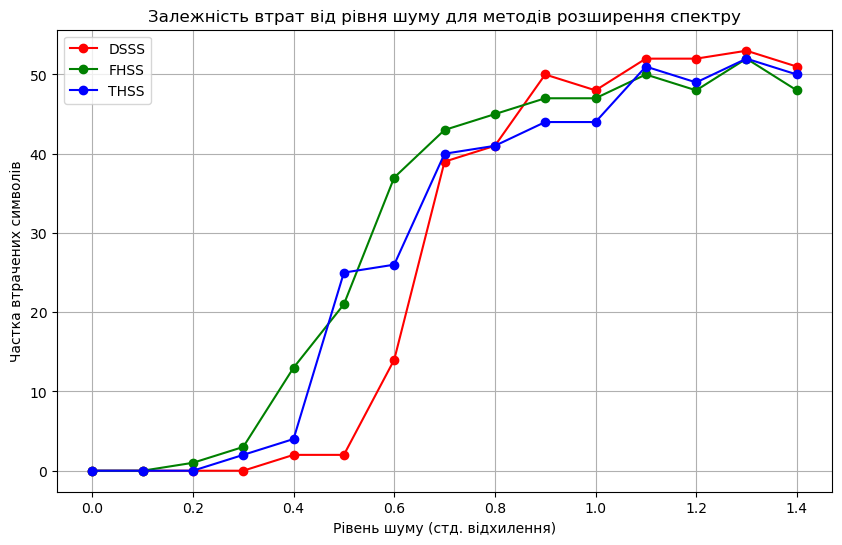

In [6]:
# Візуалізація залежності втрат від рівня шуму різних методів розширення спектру
colors = ['red', 'green', 'blue']
plt.figure(figsize=(10, 6))
for i, method in enumerate(method_names):
    noise_levels = sorted(losses_per_method[method].keys())
    losses = [losses_per_method[method][nl] for nl in noise_levels]
    losses_percents = [l / len(message) for l in losses]
    plt.plot(noise_levels, losses, color=colors[i], marker='o', label=method)

plt.xlabel('Рівень шуму (стд. відхилення)')
plt.ylabel('Частка втрачених символів')
plt.title('Залежність втрат від рівня шуму для методів розширення спектру')
plt.legend()
plt.grid(True)
plt.show()